<a href="https://colab.research.google.com/github/Sanchita210507/AML-Practicals/blob/main/AML_Exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.model_selection import GridSearchCV

**Mount Google Drive and Load Dataset**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Bank_Loan_Approval_Dataset.csv'

df = pd.read_csv(file_path)

print("First 5 Rows of Dataset:")
print(df.head())

Mounted at /content/drive
First 5 Rows of Dataset:
   Applicant_Income  Coapplicant_Income  Loan_Amount  Loan_Term_Months  \
0            136958               26736       580089               300   
1            146932                 854       200262               300   
2            118694               38623       492905               240   
3            134879                7392       285362               120   
4            125268               55680       494209                60   

   Credit_Score Employment_Type  Existing_Liabilities Property_Area  Age  \
0           369   Self-employed                210977         Urban   38   
1           551        Salaried                 12910         Rural   47   
2           714   Self-employed                335623         Rural   54   
3           744        Salaried                470951    Semi-Urban   47   
4           481   Self-employed                 81264    Semi-Urban   37   

   Loan_Status  
0            0  
1            

**Dataset Information**

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(150, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Applicant_Income      150 non-null    int64 
 1   Coapplicant_Income    150 non-null    int64 
 2   Loan_Amount           150 non-null    int64 
 3   Loan_Term_Months      150 non-null    int64 
 4   Credit_Score          150 non-null    int64 
 5   Employment_Type       150 non-null    object
 6   Existing_Liabilities  150 non-null    int64 
 7   Property_Area         150 non-null    object
 8   Age                   150 non-null    int64 
 9   Loan_Status           150 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 11.8+ KB
None

Statistical Summary:
       Applicant_Income  Coapplicant_Income    Loan_Amount  Loan_Term_Months  \
count        150.000000          150.000000     150.000000        150.000000   
mean      

**Handle Missing Values and Encode Data**

In [ ]:
# Remove Missing Values
df = df.dropna()

# Encode Categorical Data
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("Data Preprocessing Completed")

Data Preprocessing Completed


**Split Features and Target**

In [ ]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Size:", len(X_train))

print("Testing Data Size:", len(X_test))

Training Data Size: 120
Testing Data Size: 30


**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


**PCA Visualization**

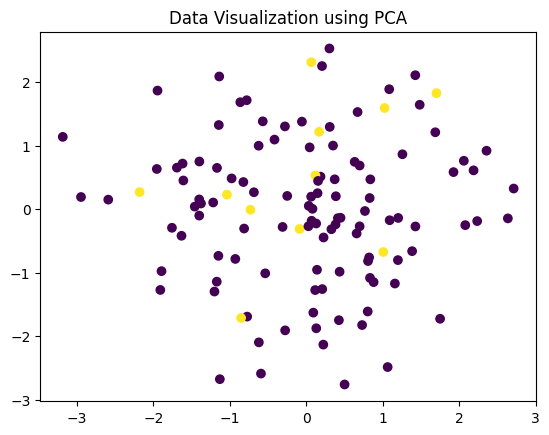

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_train
)

plt.title("Data Visualization using PCA")

plt.show()

**Train SVM Models**

In [ ]:
# Linear Kernel
svm_linear = SVC(
    kernel='linear',
    C=1
)

svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

# RBF Kernel
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

# Polynomial Kernel
svm_poly = SVC(
    kernel='poly',
    degree=3,
    C=1
)

svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

print("All SVM Models Trained Successfully")

All SVM Models Trained Successfully


**Evaluate Models**

In [ ]:
def evaluate(y_test, y_pred, name):

    print(f"\n{name}")

    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

    print("\nAccuracy:")
    print(accuracy_score(y_test, y_pred))

    print("\nPrecision:")
    print(precision_score(y_test, y_pred))

    print("\nRecall:")
    print(recall_score(y_test, y_pred))

    print("\nF1 Score:")
    print(f1_score(y_test, y_pred))

evaluate(y_test, y_pred_linear, "SVM Linear")

evaluate(y_test, y_pred_rbf, "SVM RBF")

evaluate(y_test, y_pred_poly, "SVM Polynomial")


SVM Linear
Confusion Matrix:

[[24  2]
 [ 2  2]]

Accuracy:
0.8666666666666667

Precision:
0.5

Recall:
0.5

F1 Score:
0.5

SVM RBF
Confusion Matrix:

[[26  0]
 [ 4  0]]

Accuracy:
0.8666666666666667

Precision:
0.0

Recall:
0.0

F1 Score:
0.0

SVM Polynomial
Confusion Matrix:

[[26  0]
 [ 3  1]]

Accuracy:
0.9

Precision:
1.0

Recall:
0.25

F1 Score:
0.4


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Hyperparameter Tuning**

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
